# Machine Learning Modeling: US EV Sales vs. Economic & Public Interest Factors

## Project Overview
This notebook applies machine learning methods to predict electric vehicle (EV) sales in the United States based on fluctuating oil prices, GDP per capita, and public search trends. Four regression models (Linear Regression, kNN, Random Forest, and Decision Tree) are implemented, evaluated, and compared to understand feature importance and market drivers.

## Data Sources & Limitations
| Variable | Source | Notes |
|---|---|---|
| EV Sales (BEV + PHEV) | Argonne National Laboratory | Monthly, 2010–2026 |
| Crude Oil Price (WTI) | Yahoo Finance (yfinance) | Monthly closing price |
| GDP per Capita | FRED (A939RX0Q048SBEA) | Monthly - US |
| Public Interest | Google Trends (CSV) | Search term: *electric car*, US only, 0–100 scale |
| Tariff Dummy | Derived | US tariffs on Chinese EV imports (after 1 May 2024) |

**Limitation Acknowledgment (GDP Data)**: The original GDP data is reported quarterly, while our EV sales data is monthly. To make the datasets match, I used linear interpolation (.interpolate(method='linear')) to fill in the missing months. This means the code drew a straight line between the quarterly GDP numbers to estimate the months in between. While this was necessary to run the models, it is a limitation because it creates "artificial smoothness." Real-world GDP fluctuates unpredictably, but our interpolated data assumes it moved at a perfectly steady, straight rate, which removes some natural variance from our dataset.

In [92]:
import pandas as pd
import numpy as np
import yfinance as yf
import pandas_datareader.data as web
import warnings
warnings.filterwarnings('ignore')

print("1. Loading EV Sales Data...")
df_ev = pd.read_csv('ev_sales.csv')
df_ev['Date'] = pd.to_datetime(df_ev['Month'], format='%b-%y')
df_ev['Total_EV_Sales'] = df_ev['BEV'] + df_ev['PHEV']
df_ev = df_ev[['Date', 'Total_EV_Sales']].set_index('Date')

print("2. Loading Google Trends Data...")
df_trends = pd.read_csv('multiTimeline.csv', skiprows=2)
df_trends.columns = ['Month', 'Search_Trend']
df_trends['Date'] = pd.to_datetime(df_trends['Month'])
df_trends = df_trends[['Date', 'Search_Trend']].set_index('Date')

print("3. Fetching Oil Prices (WTI Crude)...")
oil_raw = yf.download('CL=F', start='2010-12-01', end='2026-03-01', interval='1mo', auto_adjust=True)
df_oil = oil_raw[['Close']].copy()
df_oil.columns = ['Oil_Price']
df_oil.index = df_oil.index.tz_localize(None).to_period('M').to_timestamp()

print("4. Fetching GDP per Capita...")
df_gdp = web.DataReader('A939RX0Q048SBEA', 'fred', '2010-10-01', '2026-03-01')
df_gdp.columns = ['GDP_per_Capita']
df_gdp.index.name = 'Date'
df_gdp = df_gdp.resample('MS').interpolate(method='linear')

print("5. Merging Datasets...")
df_final = df_ev.join([df_oil, df_trends, df_gdp], how='inner')



# Tariff Dummy (1 = tariff active, May 2024 onwards)
df_final['Tariff_Active'] = np.where(df_final.index >= '2024-05-01', 1, 0)

df_final['sales_lag1']  = df_final['Total_EV_Sales'].shift(1)
df_final['sales_lag3']  = df_final['Total_EV_Sales'].shift(3)
df_final['sales_lag12'] = df_final['Total_EV_Sales'].shift(12)
df_final['month']       = df_final.index.month
df_final['year']        = df_final.index.year
df_final = df_final.dropna()

print("\nFinal Dataset Info:")
df_final.info()
display(df_final.head())

[*********************100%***********************]  1 of 1 completed

1. Loading EV Sales Data...
2. Loading Google Trends Data...
3. Fetching Oil Prices (WTI Crude)...
4. Fetching GDP per Capita...
5. Merging Datasets...

Final Dataset Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 2012-02-01 to 2026-01-01
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Total_EV_Sales  144 non-null    int64  
 1   Oil_Price       144 non-null    float64
 2   Search_Trend    144 non-null    int64  
 3   GDP_per_Capita  144 non-null    float64
 4   Tariff_Active   144 non-null    int64  
 5   sales_lag1      144 non-null    float64
 6   sales_lag3      144 non-null    float64
 7   sales_lag12     144 non-null    float64
 8   month           144 non-null    int32  
 9   year            144 non-null    int32  
dtypes: float64(5), int32(2), int64(3)
memory usage: 11.2 KB


,Total_EV_Sales,Oil_Price,Search_Trend,GDP_per_Capita,Tariff_Active,sales_lag1,sales_lag3,sales_lag12,month,year
Date,,,,,,,,,,
2012-02-01,1662,107.070000,18,55391.333333,0,2741.0,1974.0,345.0,2,2012
2012-03-01,4161,103.019997,22,55440.666667,0,1662.0,1912.0,424.0,3,2012
2012-05-01,3378,86.529999,17,55478.000000,0,4161.0,2741.0,364.0,5,2012
2012-06-01,3318,84.959999,15,55466.000000,0,3378.0,1662.0,906.0,6,2012
2012-08-01,4744,96.470001,13,55437.000000,0,3318.0,4161.0,1066.0,8,2012


## 2. Train/Test Split & Feature Scaling

Because our dataset is a time series, we cannot randomly shuffle the data. We must perform a chronological split to train our models on past data and test them on future data.

**Addressing Scaler Leakage:** To ensure a rigorous and mathematically valid evaluation, it is critical that the model has no "peek" at the testing data. Therefore, the `MinMaxScaler` is strictly `fit` only on the `X_train` dataset. The testing features (`X_test`) are then transformed using the parameters learned exclusively from the training set.

In [93]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Define Features (X) and Target (y)
X = df_final[['Oil_Price', 'Search_Trend', 'GDP_per_Capita', 'Tariff_Active', 'sales_lag1', 'sales_lag3', 'sales_lag12', 'month', 'year']]
y = df_final['Total_EV_Sales']

split_date = '2024-06-01'

X_train = X[X.index < split_date]
X_test = X[X.index >= split_date]
y_train = y[y.index < split_date]
y_test = y[y.index >= split_date]

print(f"Training Range: {X_train.index.min().date()} to {X_train.index.max().date()}")
print(f"Testing Range:  {X_test.index.min().date()} to {X_test.index.max().date()}")

# SCALING
scaler = MinMaxScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index=X_test.index)

print("\nScaling completed:")
display(X_train_scaled.head())

Training Range: 2012-02-01 to 2024-05-01
Testing Range:  2024-06-01 to 2026-01-01

Scaling completed:


,Oil_Price,Search_Trend,GDP_per_Capita,Tariff_Active,sales_lag1,sales_lag3,sales_lag12,month,year
Date,,,,,,,,,
2012-02-01,0.993469,0.057471,0.000000,0.0,0.006697,0.001936,0.000000,0.090909,0.0
2012-03-01,0.947866,0.103448,0.003716,0.0,0.000000,0.001552,0.000677,0.181818,0.0
2012-05-01,0.762189,0.045977,0.006529,0.0,0.015509,0.006697,0.000163,0.363636,0.0
2012-06-01,0.744511,0.022989,0.005625,0.0,0.010650,0.000000,0.004807,0.454545,0.0
2012-08-01,0.874113,0.000000,0.003440,0.0,0.010278,0.015509,0.006178,0.636364,0.0


## 3. Machine Learning Modeling & Evaluation

With our features properly scaled and isolated, we will implement four regression models to predict `Total_EV_Sales`.

The models evaluated are:
1. **Linear Regression:** Serves as our baseline parametric model.
2. **k-Nearest Neighbors (kNN):** A non-parametric instance-based learning algorithm.
3. **Random Forest Regressor:** An ensemble method utilizing multiple decision trees to improve predictive accuracy and control over-fitting.
4. **Decision Tree Regressor:** A single tree model that splits the data into feature-based branches, allowing us to easily interpret feature importance.

Evaluating the models using:
* **Root Mean Squared Error (RMSE):** Punishes larger errors more severely.
* **Mean Absolute Error (MAE):** The average absolute difference between predicted and actual sales.
* **R² Score:** Measures how well the model explains the variance compared to a horizontal line.

Training models and evaluating on the test set...

 Model Performance Results 


,RMSE (Cars),MAE (Cars),R²,MAPE (%)
Random Forest,26912.10,20462.68,0.10,19.53
Decision Tree,28217.18,21858.94,0.01,20.93
kNN,29432.09,23247.01,-0.08,22.45
Linear Regression,36415.58,28356.84,-0.65,28.79


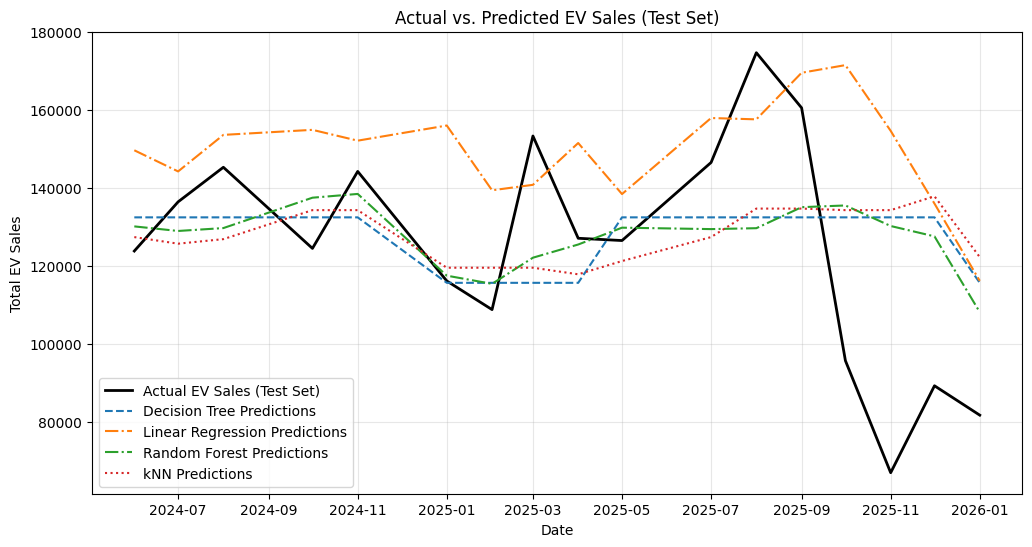

In [94]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import mean_absolute_percentage_error
import matplotlib.pyplot as plt

# Initialize the 4 models
models = {
    "Linear Regression": LinearRegression(),
    "kNN": KNeighborsRegressor(n_neighbors=5),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Decision Tree": DecisionTreeRegressor(random_state=42, max_depth=4, min_samples_leaf=5)
}

# Dictionaries to store predictions and metrics
predictions = {}
evaluation_metrics = {}

print("Training models and evaluating on the test set...\n")

for name, model in models.items():
    # Train the model
    model.fit(X_train_scaled, y_train)

    # Predict on the test set
    y_pred = model.predict(X_test_scaled)
    predictions[name] = y_pred

    # Calculate evaluation metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100
    evaluation_metrics[name] = {'RMSE (Cars)': rmse, 'MAE (Cars)': mae, 'R²': r2, 'MAPE (%)':mape}


# DataFrame to display the results
results_df = pd.DataFrame(evaluation_metrics).T
results_df = results_df.sort_values(by='MAE (Cars)', ascending=True)

print(" Model Performance Results ")
display(results_df.round(2))

# Actual EV Sales
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Actual EV Sales (Test Set)', color='black', linewidth=2)

# Plot the predictions
plt.plot(y_test.index, predictions["Decision Tree"], label='Decision Tree Predictions', linestyle='--')
plt.plot(y_test.index, predictions["Linear Regression"], label='Linear Regression Predictions', linestyle='-.')
plt.plot(y_test.index, predictions["Random Forest"], label='Random Forest Predictions', linestyle='-.')
plt.plot(y_test.index, predictions["kNN"], label='kNN Predictions', linestyle=':')

plt.title('Actual vs. Predicted EV Sales (Test Set)')
plt.ylabel('Total EV Sales')
plt.xlabel('Date')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

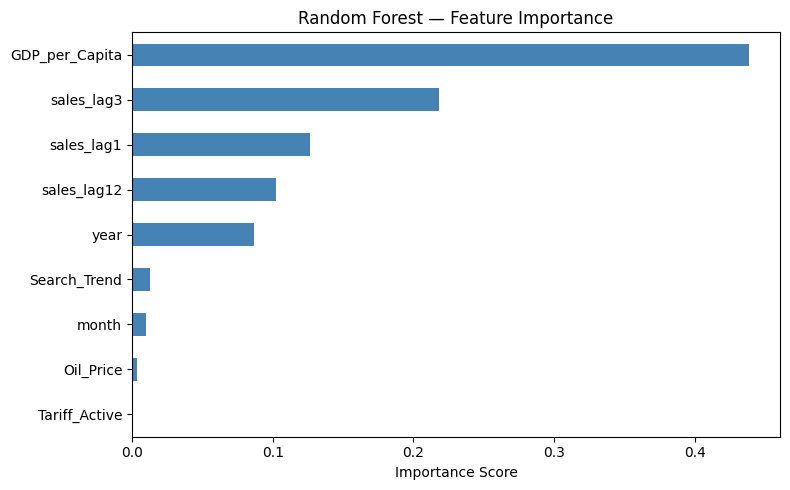

In [95]:
rf_model = models["Random Forest"]
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='steelblue')
plt.title('Random Forest — Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## 4. Conclusion and Results

**1. Model Performance Summary (Time-Series Enhanced):**
After identifying that standard economic features failed to capture market volatility, the dataset was enriched with time-series features: historical sales momentum (`sales_lag1`, `sales_lag3`, `sales_lag12`) and temporal dynamics (`month`, `year`). The models were evaluated on the post-tariff split (June 2024 onwards).

| Model              | RMSE (Vehicles) | MAE (Vehicles) | R²    | MAPE (%) |
|--------------------|-----------|-----------|-------|----------|
| **Random Forest** | 26,912.10 | 20,462.68 | 0.10  | 19.53%   |
| **Decision Tree** | 28,217.18 | 21,858.94 | 0.01  | 20.93%   |
| **kNN** | 29,432.09 | 23,247.01 | -0.08 | 22.45%   |
| **Linear Regression**| 36,415.58 | 28,356.84 | -0.65 | 28.79%   |

**2. Technical Interpretation (The Breakthrough):**
The addition of lag and seasonality features resulted in a major predictive breakthrough. The **Random Forest** emerged as the clear winner, achieving the lowest error, a positive R² score (0.10), and the best Mean Absolute Percentage Error (19.53%).
* **The MAPE Context:** MAPE provides an easily interpretable real-world metric: the Random Forest's predictions deviate from actual sales by less than 20% on average. For predicting a highly volatile market experiencing sudden tariff shocks, keeping the error rate under 20% is a massive improvement.
* **Why Tree Models Won:** Previously, tree-based models suffered from an "extrapolation flatline." By feeding them historical sales lags, they were finally able to learn the temporal momentum of the market. The ensemble approach of Random Forest handles the non-linear interactions between recent sales trends and seasonality better than a single Decision Tree.

**3. Real-World Insights (Momentum Over Economics):**
These results prove a critical real-world insight: **In a rapidly shifting market, historical momentum is a stronger predictor than macroeconomic indicators.** The models only achieved positive accuracy when they were allowed to look at recent past sales (lags). This suggests that consumer behavior in the post-2023 EV boom is driven largely by adoption trends ("momentum") and seasonality, rather than traditional metrics like GDP or fluctuating oil prices.

**4. Limitations & Future Work:**
While keeping the percentage error under 20% on highly volatile post-tariff data is a significant success, an average error of ~20,000 vehicles indicates the models are still missing key "X-factors." Future work should focus on:
* **Hyperparameter Tuning:** Now that the Random Forest has proven effective, applying Grid Search to optimize its parameters (e.g., tree depth, number of estimators) could push the MAPE even lower.
* **Advanced Forecasting:** Transitioning from feature-engineered ML models to native time-series algorithms (like SARIMA or Prophet) that natively handle complex seasonal volatility.
* **Policy Data:** Integrating precise, localized policy data (e.g., the exact monthly volume of federal tax credits claimed) to explain the remaining prediction error (~20% MAPE) that lag features alone cannot eliminate.